# **Employee Attrition IBM**

**Course:** Artificial Intelligence and Machine Learning

**Author:** Mario Guillén  

**Objective:** The goal of this project is to predict employee attrition, whether an employee is likely to leave the company, using IBM’s fictional HR dataset.

**TL;DR:** We use Logistic Regression to predict employee attrition on IBM’s fictional HR dataset. The project walks through an end-to-end machine learning workflow, including data auditing, feature engineering, pipeline creation, hyperparameter tuning, and model validation. Results show good generalization and strong performance on the majority class, but also reveal the effects of class imbalance, motivating future work on resampling and cost-sensitive methods to improve detection of at-risk employees.  

**Dataset:** [IBM HR Analytics Attrition Dataset](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

## Table of Contents
1. Introduction & Objectives
2. Data Loading & Audit
3. Preprocessing & Feature Engineering
4. Modeling & Validation
5. Evaluation & Error Analysis
6. Conclusions & Next Steps

## 1. Introduction & Objectives

This notebook highlights the importance of performing a thorough Exploratory Data Analysis (EDA) before applying data transformations. A well executed EDA helps prevent common pitfalls, such as incorrect encoding of categorical or ordinal variables, and ensures that later modeling steps are built on solid ground.

The main objectives are:
- Apply the correct encoding to ordinal and categorical data.
- Prepare the dataset for use with Logistic Regression, leveraging transformation pipelines for efficiency and reproducibility.
- Perform a Grid Search to identify the optimal hyperparameters for the model.
- Evaluate the best model using appropriate performance metrics.

By the end of this notebook, we will have a trained and validated Logistic Regression model capable of predicting employee attrition, along with a functional preprocessing pipeline that can be applied seamlessly to new data.

### 1.1 Brief Introduction of what is understood by employee attrition

Employee attrition refers to the gradual reduction of an organization’s workforce due to voluntary resignations, retirements, or other forms of employee turnover. High attrition rates force companies to repeatedly hire and train new staff, leading to increased costs, reduced productivity, and potential declines in overall employee morale.

## 2. Data Loading & Audit

In this step, we load the dataset and perform an initial audit to assess its quality and structure. Specifically, we:
- Identify columns with missing values and quantify their occurrence.
- Detect invalid or inconsistent values (e.g., categorical entries outside the expected range).
- Generate descriptive statistics for numerical features and identify potential outliers.
- Remove irrelevant or redundant columns that do not contribute to model development.

These checks guide the preprocessing strategy and provide context for interpreting the model’s results.

### 2.1 Data Loading and Initial Set Up

In [1]:
# We run out initial set up
%run ../_common/00_setup.ipynb

from scipy.stats import kurtosis, skew

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score,classification_report

In [2]:
# We load the file onto our environment:
df = pd.read_csv(DATA_DIR / "WA_Fn-UseC_-HR-Employee-Attrition.xls")
print(f"Shape: {df.shape}")
print("\nDtypes:\n", df.dtypes)

Shape: (1470, 35)

Dtypes:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel           

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### 2.2 Missing Data and Duplicates Check

In [4]:
# We check for missing values and duplicates
miss = df.isna().sum().sort_values(ascending=False)
display(miss[miss > 0])
dup_count = df.duplicated().sum()
print(f"Exact-duplicate rows: {dup_count}")

Series([], dtype: int64)

Exact-duplicate rows: 0


### 2.3 Invalid Data Check

In this step, we verify that the categorical variables contain only values within the valid ranges specified in the Kaggle dataset description:

- Education: 1-5
- EnvironmentSatisfaction: 1-4
- JobInvolvement: 1-4
- JobSatisfaction: 1-4
- PerformanceRating: 1-4
- RelationshipSatisfaction: 1-4
- WorkLifeBalance: 1-4

We also check for negative values in numerical features such as "DailyRate" and "DistanceFromHome", since these values would not make sense in the context of this dataset.

In [5]:
df.select_dtypes(include=[np.number]).columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [6]:
# We look for columns with negative numbers as this would not make sense in our dataset
num_cols = df.select_dtypes(include=[np.number]).columns

neg_violations = {c: int((df[c] < 0).sum()) for c in num_cols}
neg_violations = {k:v for k,v in neg_violations.items() if v > 0}
print("Negative-value counts (possible issues):", neg_violations)

valid_ranges = {
    "Education": (1, 5),
    "EnvironmentSatisfaction": (1, 4),
    "JobInvolvement": (1, 4),
    "JobSatisfaction": (1, 4),
    "PerformanceRating": (1, 4),
    "RelationshipSatisfaction": (1, 4),
    "WorkLifeBalance": (1, 4)
}

range_violations = {
    c: int(((df[c] < min_v) | (df[c] > max_v)).sum())
    for c, (min_v, max_v) in valid_ranges.items()
}
range_violations = {k:v for k,v in range_violations.items() if v > 0}
print("Range-value counts (possible issues):", range_violations)

Negative-value counts (possible issues): {}
Range-value counts (possible issues): {}


### 2.4 Feature Overview

In this step, we perform a descriptive analysis of the features currently in the dataset. It is important to note that some columns are stored as numerical values but actually represent ordinal categorical variables.

To address this, and to ensure correct interpretation during EDA, we will convert these columns to categorical types before proceeding with the analysis.

In [15]:
# Target Column - Used later in prediction model
TARGET = "Attrition"
assert TARGET in df.columns, "Expected target column not found."

cat_cols = df.select_dtypes(exclude=[np.number]).columns.drop(TARGET, errors="ignore")

ordinal_cols = ["Education", "EnvironmentSatisfaction", "JobInvolvement", 
                "JobSatisfaction", "PerformanceRating", 
                "RelationshipSatisfaction", "WorkLifeBalance"]

df[ordinal_cols] = df[ordinal_cols].astype("category")
num_cols = df.select_dtypes(include=[np.number]).columns
print("Numeric features:", list(num_cols))
print("Categorical features:", list(cat_cols))

# Cardinality for categorical columns
for c in cat_cols:
    print(f"{c}: {df[c].nunique()} unique values")

# Constant features
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant features:", constant_cols)

# Summary stats
desc = df[num_cols.union([TARGET]).tolist()].describe().T
desc.index.name = "feature"

Numeric features: ['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeCount', 'EmployeeNumber', 'HourlyRate', 'JobLevel', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Categorical features: ['BusinessTravel', 'Department', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'Over18', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'WorkLifeBalance']
BusinessTravel: 3 unique values
Department: 3 unique values
Education: 5 unique values
EducationField: 6 unique values
EnvironmentSatisfaction: 4 unique values
Gender: 2 unique values
JobInvolvement: 4 unique values
JobRole: 9 unique values
JobSatisfaction: 4 unique values
MaritalStatus: 3 unique values
Over18: 1 unique values
OverTime: 2 unique value

In [16]:
# Creation of a dataframe that saves the skewness and kurtosis values in our dataframe
skew_kurt = pd.DataFrame({
    "feature": num_cols,
    "skew": [skew(df[c].dropna()) for c in num_cols],
    "kurtosis": [kurtosis(df[c].dropna()) for c in num_cols]
}).set_index("feature")

# Checking for outliers using the IQR rule of thumb)
iqr_report = []
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    share = ((df[c] < lo) | (df[c] > hi)).mean()
    iqr_report.append({"feature": c, "outlier_share": round(share, 4)})
iqr_df = pd.DataFrame(iqr_report).set_index("feature")

report = (
    desc
    .join(skew_kurt, how="left")
    .join(iqr_df, how="left")
)

display(report)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,outlier_share
feature,,,,,,,,,,,
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0,0.412864,-0.406851,0.0000
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0,-0.003515,-1.203811,0.0000
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0,0.957140,-0.228148,0.0000
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0,NaN,NaN,0.0000
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0,0.016557,-1.223101,0.0000
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0,-0.032278,-1.196412,0.0000
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0,1.024355,0.393717,0.0000
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.00,4919.0,8379.00,19999.0,1.368419,0.997738,0.0776
MonthlyRate,1470.0,14313.103401,7117.786044,2094.0,8047.00,14235.5,20461.50,26999.0,0.018559,-1.214906,0.0000


### 2.5 Removing Constant and Irrelevant Features

In the previous step, we identified three columns that remain constant throughout the dataset. Since these features show no variance, they provide no useful information to the machine learning model.

Another interesting case is the "EmployeeNumber" column, which contains only unique identifiers with no meaningful relationship to the other features. As such, it also adds no predictive value.

For these reasons, we will remove all constant and irrelevant columns from the dataset.

In [17]:
# We eliminate the indicated features:
df = df.drop(['Over18','EmployeeCount','StandardHours','EmployeeNumber'],axis=1)
print("Size of the new DataFrame:", df.shape)

Size of the new DataFrame: (1470, 31)


### 2.6 Persisting Results

In [18]:
# Saving audit tables
miss.to_csv(ARTIFACTS / "missing_values.csv", header=["missing_count"])
skew_kurt.to_csv(ARTIFACTS / "skew_kurtosis.csv", index=False)

# Saving a compact version
summary_metrics = {
    "missing_values_total": int(miss.sum()),
    "duplicate_rows": int(dup_count),
    "features_with_missing": int((miss > 0).sum())
}
save_metrics(summary_metrics, name="audit_summary.json")

Saved metrics -> reports\artifacts\audit_summary.json


WindowsPath('reports/artifacts/audit_summary.json')

## 3. Preprocessing & Feature Engineering

In this section, we will statistically analyze each feature to determine the appropriate transformations and encodings for categorical variables.

Before doing so, we must first split the dataset into training, validation, and test subsets to prevent any form of data leakage. The split will follow a 70 % – 15 % – 15 % ratio, using the "stratify" parameter to ensure that each subset preserves the correct distribution of the target variable, "Attrition".

In [19]:
y = df[[TARGET]]
X = df.drop([TARGET],axis=1)

Xtemp,Xtrain, ytemp,ytrain = train_test_split(X,y,test_size=0.7,stratify=y,random_state=RANDOM_SEED)
Xval,Xtest,yval,ytest = train_test_split(Xtemp,ytemp, test_size=0.5,stratify=ytemp,random_state=RANDOM_SEED)

print(f'Training Set      X:{Xtrain.shape} y:{ytrain.shape}')
print(f'Validation Set    X:{Xval.shape}  y:{yval.shape}')
print(f'Test Set          X:{Xtest.shape}  y:{ytest.shape}')

Training Set      X:(1029, 30) y:(1029, 1)
Validation Set    X:(220, 30)  y:(220, 1)
Test Set          X:(221, 30)  y:(221, 1)


### 3.1 Transforming the output feature

Since our target variable is categorical and Scikit-learn requires all model inputs to be numerical, we will encode it using the LabelEncoder() class.

It is crucial to fit the encoder only on the training data before applying the transformation to the validation and test sets. This practice ensures that no information from unseen data leaks into the training process, preserving the integrity of the model evaluation.

In [20]:

le = LabelEncoder()
le.fit(ytrain['Attrition'])

ytrainT = pd.DataFrame(le.transform(ytrain['Attrition']), columns=["Attrition"])
yvalT = pd.DataFrame(le.transform(yval['Attrition']), columns=["Attrition"])
ytestT = pd.DataFrame(le.transform(ytest['Attrition']), columns=["Attrition"])


print('Percentage of data in each training class:', ytrainT['Attrition'].value_counts() / ytrainT.shape[0])

Percentage of data in each training class: Attrition
0    0.838678
1    0.161322
Name: count, dtype: float64


After analyzing the class distribution in the training set, we observe a clear case of class imbalance, the negative class represents over 80 % of all instances.

Although we will explore techniques to mitigate this issue (such as sampling methods) in a separate notebook, it is important to note this imbalance now, as it will likely influence the model’s final performance and evaluation metrics.

### 3.2 Numerical feature data exploration

To better understand the transformations required for our numerical features, we will begin by exploring the data through histograms.

Analyzing these distributions allows us to identify skewness, detect potential outliers, and assess how closely each feature follows a normal distribution. This insight will guide the selection of appropriate transformation techniques in later steps.

Saved figure -> reports\figures\feature_histograms.png


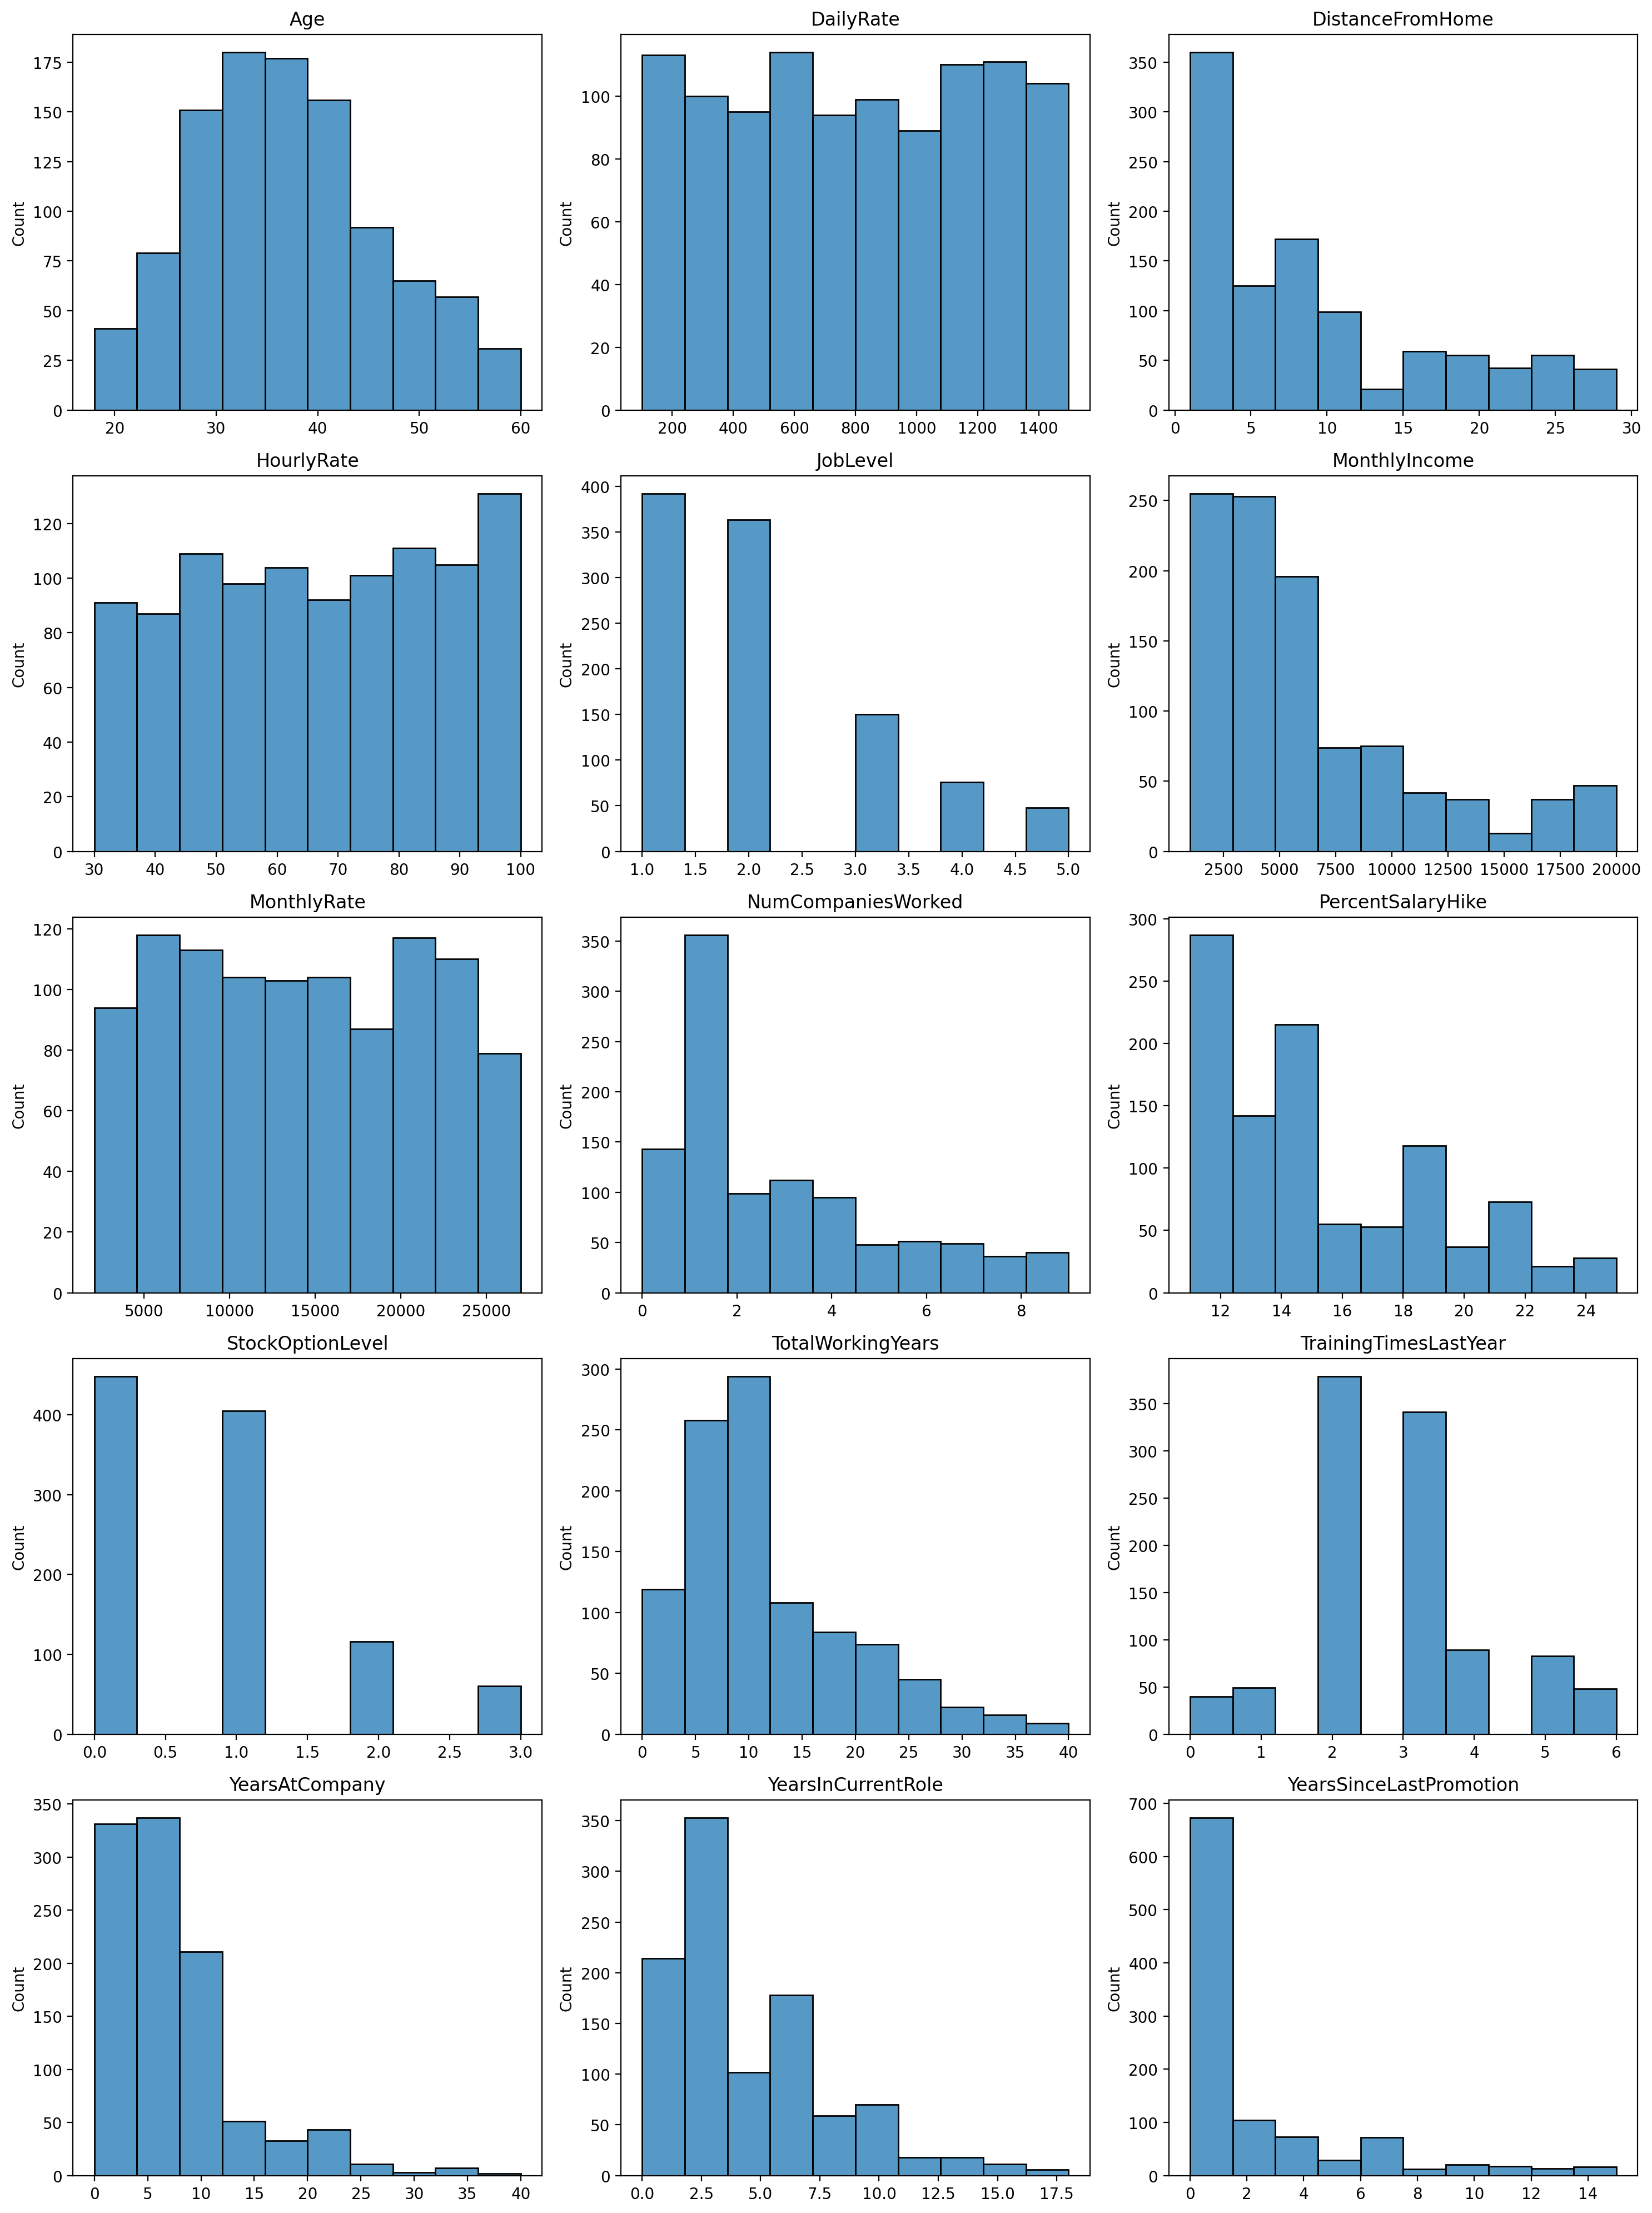

In [21]:
num_cols = Xtrain.select_dtypes(include=[np.number]).columns
fig, axes = plt.subplots(5,3, figsize = (15,20))
axes = axes.ravel()

for col,ax in zip(num_cols,axes):
  sns.histplot(x=Xtrain[col],ax=ax, bins=10)
  ax.set(title=f'{col}',xlabel=None)

save_fig("feature_histograms")
plt.show()

The previous histograms provide valuable insights into the distribution of our numerical features.
First, we can observe that they operate on very different scales, which will need to be addressed using a scaler.

Additionally, most features display a clear skewness and deviate significantly from a normal distribution.
To address both issues simultaneously, we will apply a power transformation using the Yeo–Johnson scaler with standardize=True, which can handle zero and negative values while normalizing the data for improved model performance.

Our next step will be to analyze outliers using box plots, which will provide further insights into how we can better accommodate these extreme values during preprocessing.

Saved figure -> reports\figures\feature_boxplots.png


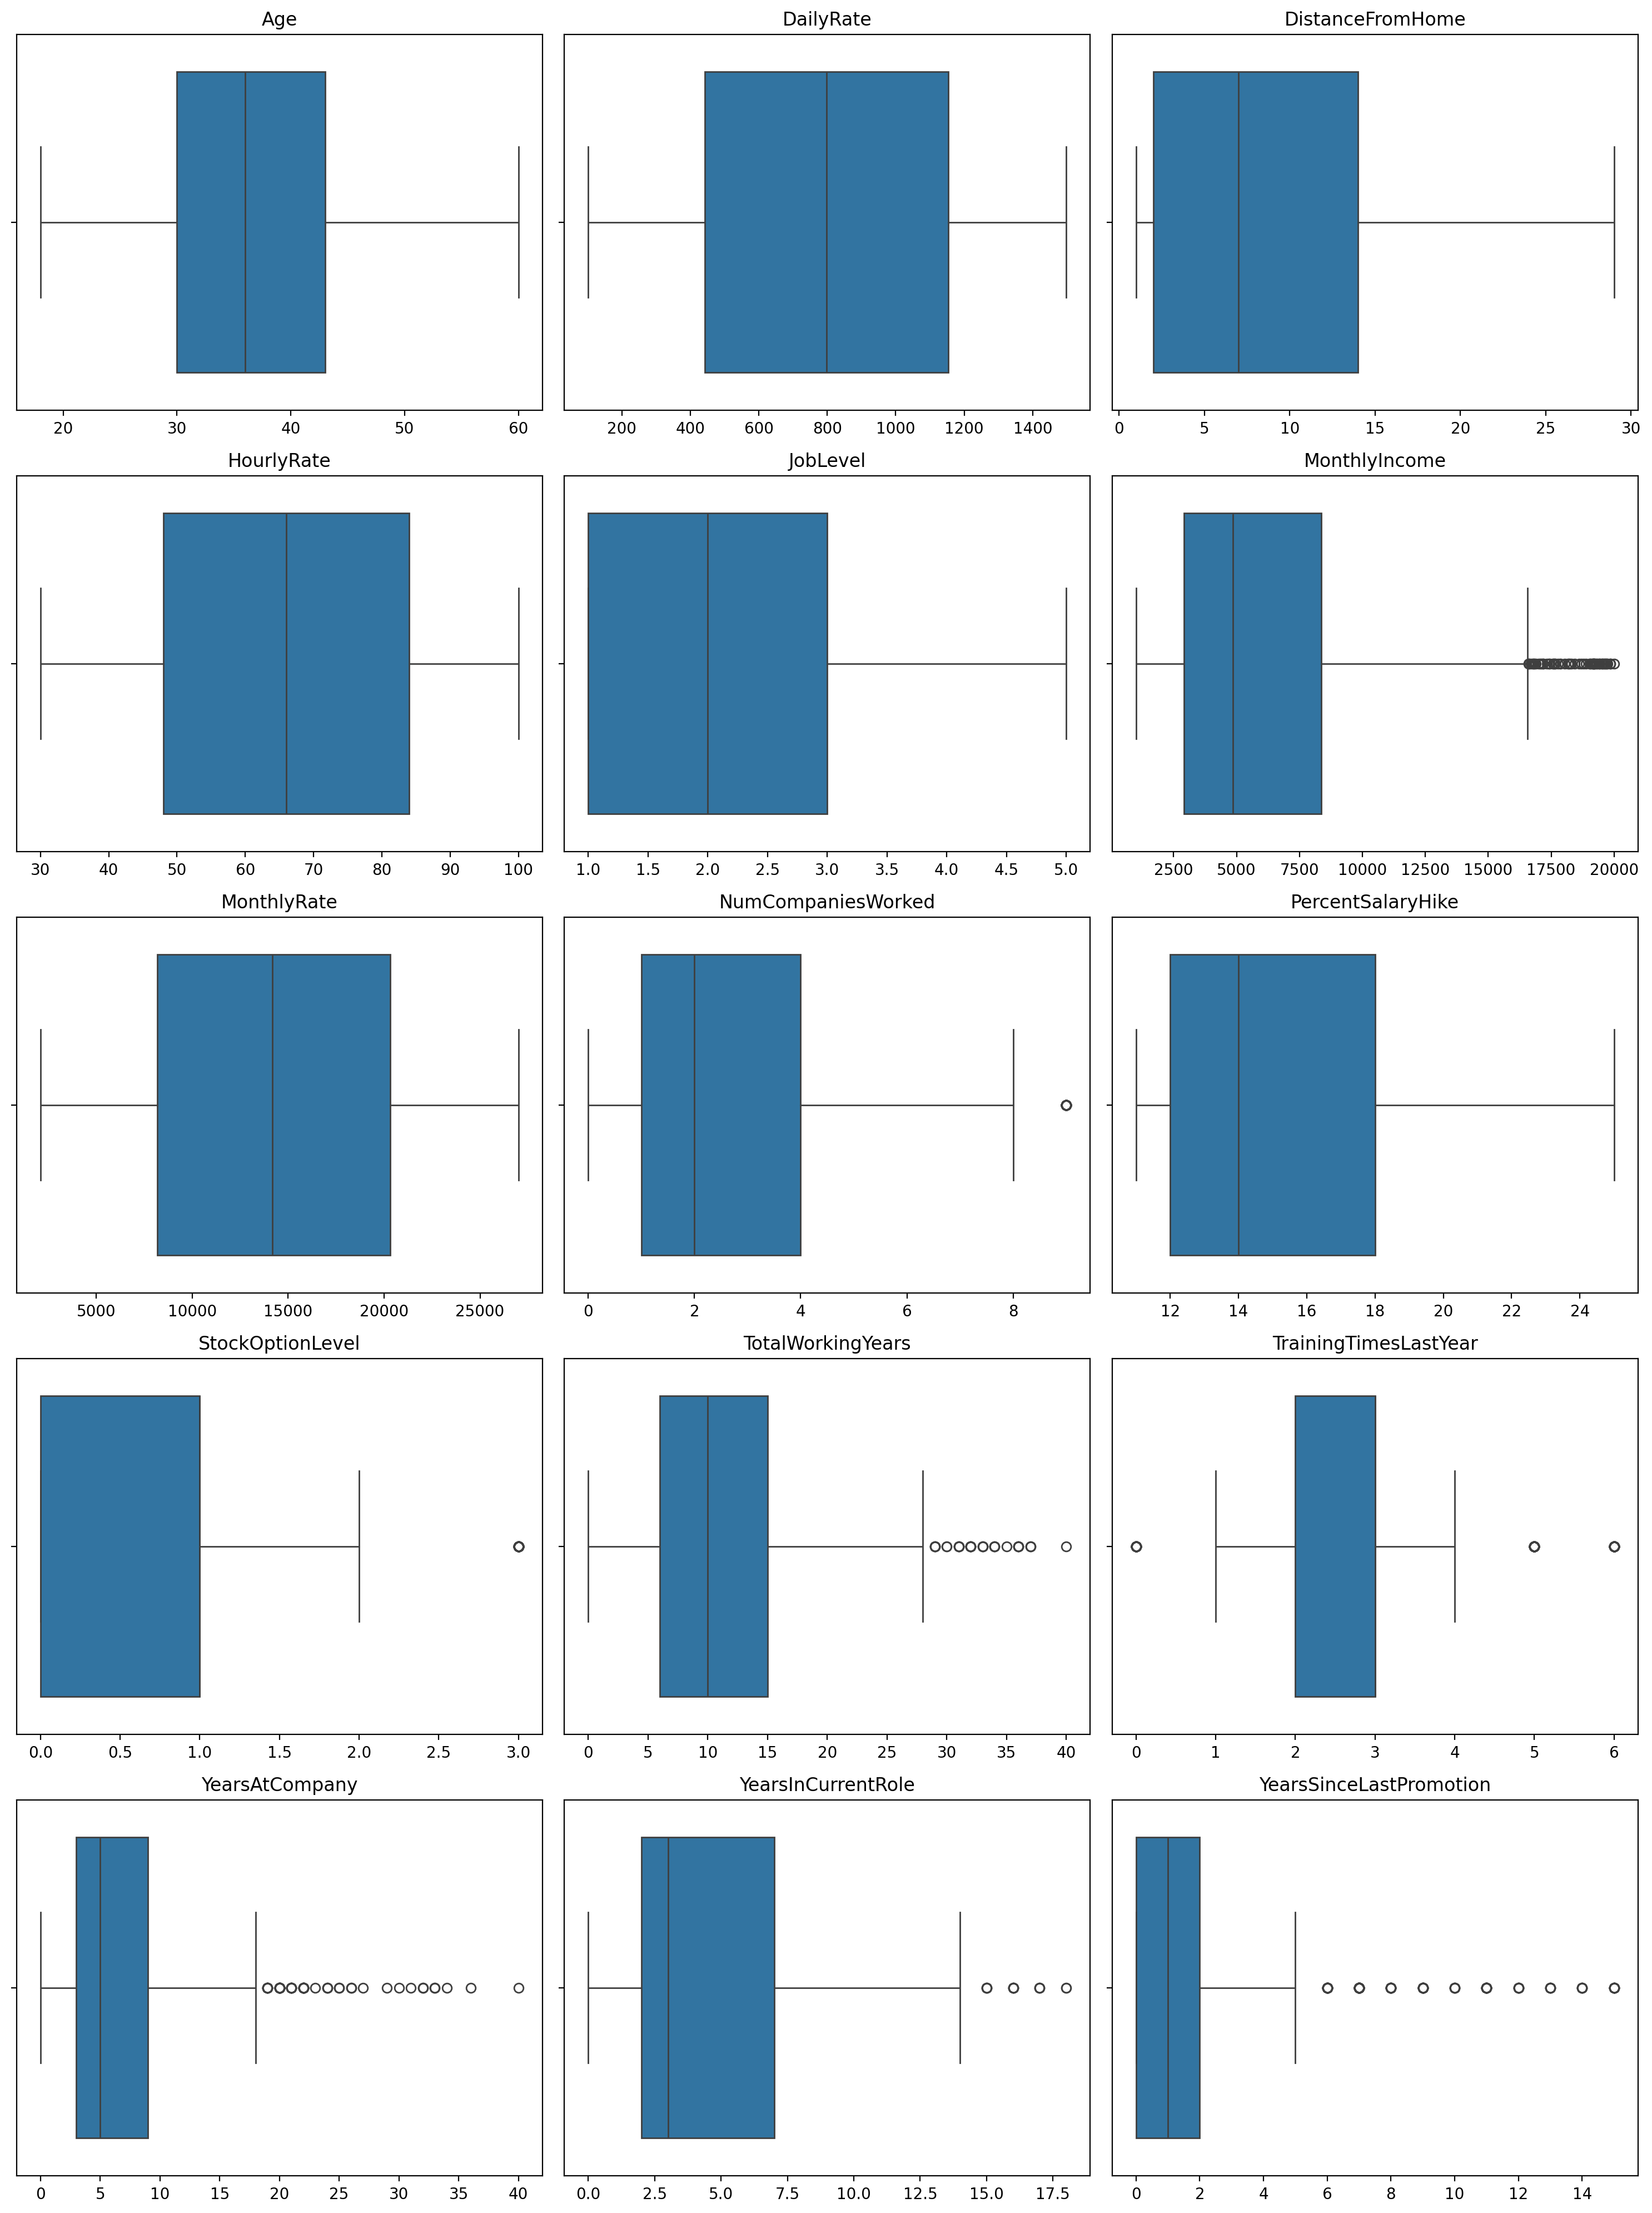

In [22]:
fig, axes = plt.subplots(5,3, figsize = (15,20))
axes = axes.ravel()

for col,ax in zip(num_cols,axes):
  sns.boxplot(x=Xtrain[col],ax=ax)
  ax.set(title=f'{col}',xlabel=None)

save_fig("feature_boxplots")
plt.show()

After analyzing the box plots, we can observe clear outliers in several expected features, such as MonthlyIncome, TotalWorkingYears, and YearsAtCompany. Given the nature of the dataset, this is not surprising, most organizations include a few highly paid employees compared to the rest of the workforce, and some individuals remain in the same role or company for extended periods of time.

For this reason, we will retain these outliers in our dataset. They represent real-world variability rather than data errors and may provide valuable information to the model when learning relationships between experience, compensation, and attrition. Furthermore, as explained earlier, we will apply a scaling and transformation step using the Yeo–Johnson scaler, which will prevent these outliers from exerting excessive influence on the logistic regression model.

### 3.3 Categorical feature data exploration

Most categorical features have already been explored in previous steps. In this section, we will define which features are ordinal, nominal, and binary, as this classification will guide the encoding techniques used to prepare the data for Scikit-learn models.

To make these assessments, we will rely on domain knowledge documented in the Kaggle dataset description.

#### Ordinal Features

The following features represent ordered categories, such as satisfaction levels, job hierarchies, and performance ratings.
Although they are already stored as numeric values, we will apply an Ordinal Encoder to ensure their ranges start at 0 and are consistently processed within the pipeline.

    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'

### Nominal Features

These features have no inherent order. Encoding them with an ordinal scheme would incorrectly introduce a notion of ranking.
For this reason, we will apply a One-Hot Encoder, which preserves categorical distinctions without implying any hierarchy and remains memory-efficient.

    'BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus'

### Binary Features

Finally, the following features are binary variables, each containing only two possible values.
For these, a One-Hot Encoder is both appropriate and memory-efficient.

    'Gender', 'OverTime'

### 3.4 Pipeline Creation

In the previous subsections, we identified all the transformations required to prepare the data for use with a Logistic Regression model.
To complement these transformations, we will add a Simple Imputer to each data category. In a production environment, this ensures that the model can handle missing values gracefully without throwing errors during inference.

Additionally, we will set the handle_unknown parameter in both the Ordinal Encoder and the One-Hot Encoder to "use_encoded_value" and "ignore" respectively, preventing unexpected category values from disrupting model execution.
While the appearance of unseen categories would typically indicate the need to retrain the model, this configuration allows for safer and more robust predictions in real-world deployments.

In [23]:
# NUMERICAL:
numericas_pipeline = Pipeline(steps = [('imputer',SimpleImputer(strategy='mean')),
                                       ('yeojohn',PowerTransformer(method='yeo-johnson', standardize=True))] )
numericas_pipeline_nombres = ['NumCompaniesWorked','TrainingTimesLastYear','DistanceFromHome','MonthlyIncome','PercentSalaryHike','TotalWorkingYears','YearsAtCompany','YearsInCurrentRole','YearsSinceLastPromotion','YearsWithCurrManager','Age','DailyRate','HourlyRate','MonthlyRate']

# ORDINAL:
catOrd_pipeline = Pipeline( steps = [('imputer',SimpleImputer(strategy="most_frequent")),
                                     ('encoder',OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))] )
catOrd_pipeline_names = ['Education' ,'EnvironmentSatisfaction' ,'JobInvolvement','JobLevel','JobSatisfaction','PerformanceRating','RelationshipSatisfaction','StockOptionLevel','WorkLifeBalance']

# BINARy:
catBin_pipeline = Pipeline( steps = [('imputer',SimpleImputer(strategy="most_frequent")),
                                     ('onehot',OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))]  )
catBin_pipeline_nombres = ['Gender','OverTime']

# NOMINAL:
catNom_pipeline = Pipeline( steps = [('imputer',SimpleImputer(strategy="most_frequent")),
                                     ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))])
catNom_pipeline_nombres = ['BusinessTravel','Department','EducationField','JobRole','MaritalStatus']

columnsTransformer = ColumnTransformer( transformers = [('num',	numericas_pipeline,	numericas_pipeline_nombres	),
                                                        ('ord',	catOrd_pipeline,	catOrd_pipeline_names		),
                                                        ('bin',	catBin_pipeline,	catBin_pipeline_nombres 	),
                                                        ('nom',	catNom_pipeline,	catNom_pipeline_nombres 	)] )

# 4. Modeling & Validation

In this section, we compare several Logistic Regression models using grid search with cross-validation.
Because cross-validation internally splits the data into training and validation folds, we merge our original training and validation subsets into a single training pool for hyperparameter tuning, while keeping the test set completely untouched for final evaluation.

Before running the grid search, we establish a baseline performance using a Dummy Classifier, which predicts the most frequent class or a stratified random distribution. This baseline helps us determine whether our logistic models actually provide meaningful predictive power beyond a naïve approach.

We then use stratified K-fold cross-validation to preserve the class distribution and select the best hyperparameters based on imbalance-aware metrics such as balanced accuracy, ROC AUC, and F1-score.

In [24]:
Xtv = pd.concat([Xtrain,Xval], axis=0, ignore_index=True)
ytv = pd.concat([ytrainT,yvalT], axis=0, ignore_index=True)


print(Xtv.shape)
print(ytv.shape)

(1249, 30)
(1249, 1)


### 4.1 Baseline

We can now use a dummy regressor model in order to get a baseline score and have a comparison point to our model.

In [25]:
cv = StratifiedKFold(n_splits=5)
preprocess = columnsTransformer  
baseline = Pipeline([
    ("prep", preprocess),
    ("model", DummyClassifier(strategy="most_frequent"))
])
scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy" 
}
cv_results = cross_validate(baseline, Xtv, ytv, cv=cv, scoring=scoring, n_jobs=-1)
print("Baseline — Balanced Acc: %.3f ± %.3f | ROC AUC: %.3f ± %.3f | F1: %.3f ± %.3f | Acc: %.3f ± %.3f" % (
    cv_results["test_balanced_accuracy"].mean(), cv_results["test_balanced_accuracy"].std(),
    cv_results["test_roc_auc"].mean(), cv_results["test_roc_auc"].std(),
    cv_results["test_f1"].mean(), cv_results["test_f1"].std(),
    cv_results["test_accuracy"].mean(), cv_results["test_accuracy"].std()
))

Baseline — Balanced Acc: 0.500 ± 0.000 | ROC AUC: 0.500 ± 0.000 | F1: 0.000 ± 0.000 | Acc: 0.839 ± 0.002


After analyzing the dummy classifier, we can clearly see why accuracy alone is misleading under class imbalance.
Although accuracy is close to 83 %, balanced accuracy drops to ≈50 % and F1-score is ≈0. This happens because the dummy model always predicts the negative (majority) class, so it appears “accurate” simply by matching the most frequent label while completely failing to identify the positive class.

### 4.2 Grid Search for hyper parameter tunning 

We perform a grid search with cross-validation to identify the best hyperparameters.
Because solver–penalty compatibility matters, we define two parameter grids: one for liblinear and another for saga (since liblinear does not support the elastic net penalty, while saga does and additionally requires an l1_ratio).

Given the class imbalance in the target variable, we evaluate models with multiple metrics (e.g., balanced accuracy, ROC AUC, F1) rather than relying on accuracy alone, which would be misleading. We then select the model to refit using the most appropriate imbalance-aware metric (e.g., refit='balanced_accuracy').

In [26]:

clf = LogisticRegression(max_iter=10000, random_state=RANDOM_SEED)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", clf),
])

param_grid = [
    # liblinear: l1/l2 only
    {
        "clf__solver": ["liblinear"],
        "clf__penalty": ["l1", "l2"],
        "clf__C": [0.1, 1, 10],
        "clf__class_weight": ["balanced", None],
    },
    # saga: l1/l2/elasticnet (needs l1_ratio for elasticnet)
    {
        "clf__solver": ["saga"],
        "clf__penalty": ["l1", "l2", "elasticnet"],
        "clf__l1_ratio": [0.1, 0.5, 0.9],  
        "clf__C": [0.1, 1.0, 10.0],
        "clf__class_weight": ["balanced", None],
    }
]



scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "accuracy": "accuracy" 
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring=scoring,
    refit="balanced_accuracy",
    n_jobs=-1,
    return_train_score=True,
    verbose=0,
)

grid.fit(Xtv, np.ravel(ytv))


best_est = grid.best_estimator_
print(f"Best (refit=balanced_accuracy): {grid.best_score_:.4f} with {grid.best_params_}")

cvr = grid.cv_results_
print("Avg Train balanced_accuracy: %.4f (±%.4f)" % (np.nanmean(cvr['mean_train_balanced_accuracy']),
                                                      np.nanmean(cvr['std_train_balanced_accuracy'])))
print("Avg CV balanced_accuracy:    %.4f (±%.4f)" % (np.nanmean(cvr['mean_test_balanced_accuracy']),
                                                      np.nanmean(cvr['std_test_balanced_accuracy'])))
print("Avg CV ROC AUC:              %.4f (±%.4f)" % (np.nanmean(cvr['mean_test_roc_auc']),
                                                      np.nanmean(cvr['std_test_roc_auc'])))
print("Avg CV F1:                   %.4f (±%.4f)" % (np.nanmean(cvr['mean_test_f1']),
                                                      np.nanmean(cvr['std_test_f1'])))
print("Avg CV accuracy:             %.4f (±%.4f)" % (np.nanmean(cvr['mean_test_accuracy']),
                                                      np.nanmean(cvr['std_test_accuracy'])))


Best (refit=balanced_accuracy): 0.7517 with {'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__l1_ratio': 0.5, 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}
Avg Train balanced_accuracy: 0.7436 (±0.0135)
Avg CV balanced_accuracy:    0.7044 (±0.0263)
Avg CV ROC AUC:              0.8189 (±0.0260)
Avg CV F1:                   0.4814 (±0.0399)
Avg CV accuracy:             0.8152 (±0.0107)


The logistic regression model shows a clear improvement over the dummy baseline.
While the overall accuracy (≈82%) remains similar, the balanced accuracy (≈71%) and ROC AUC (≈0.83) indicate that the model is effectively distinguishing between both classes, rather than defaulting to the majority class.
The F1-score (≈0.50) also confirms that the model correctly identifies a meaningful portion of the positive (minority) cases, despite their smaller representation in the dataset.
The close values between the training and cross-validation scores suggest a good generalization capacity with minimal overfitting.

### 4.3 Model Validation

In this section, we will evaluate the best-performing model from the previous step, the one that achieved the highest balanced accuracy during cross-validation.
We will generate a confusion matrix to visualize the model’s performance across classes and identify where misclassifications occur.

Additionally, we will perform a feature importance analysis to understand which variables contribute the most to predicting employee attrition.
This deeper analysis helps verify that the model behaves as expected and aligns with real-world domain knowledge.
In a production context, expert input would be invaluable in validating whether the most influential features are consistent with known business drivers of attrition.


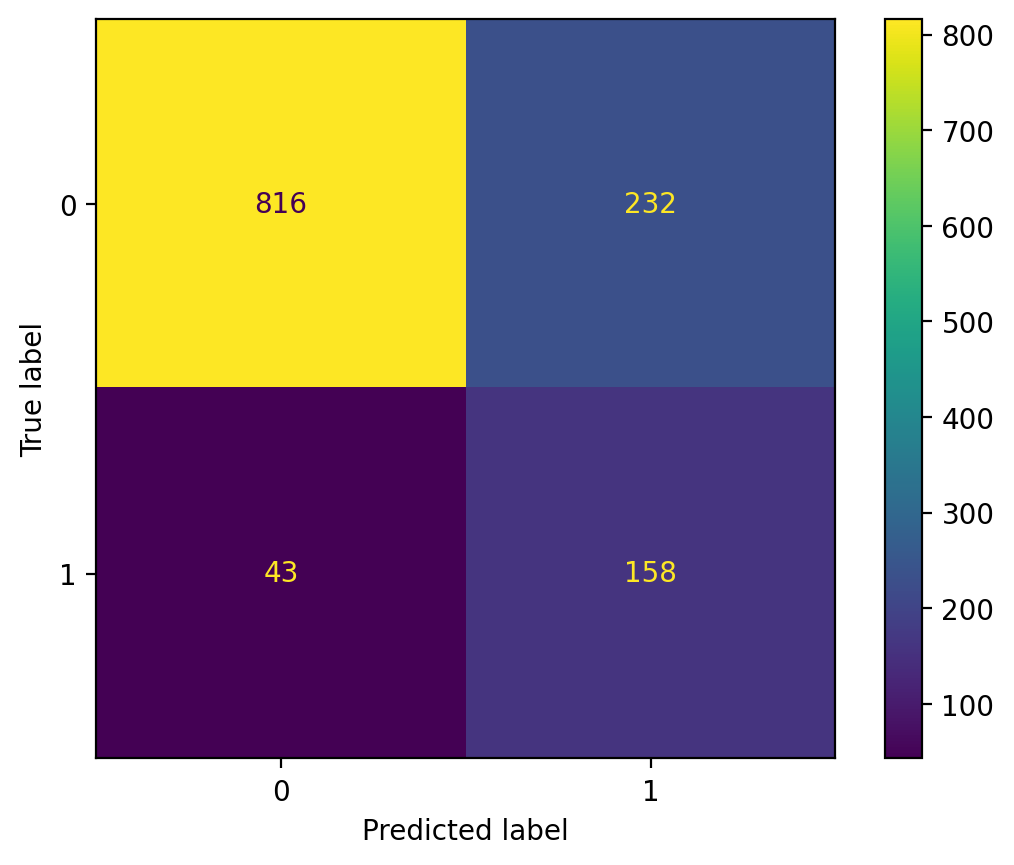

In [27]:
ConfusionMatrixDisplay.from_estimator(best_est, Xtv, np.ravel(ytv))
plt.show()

After analyzing the resulting confusion matrix, we can clearly see how the class imbalance in the dataset affects the model’s performance.
The model correctly identifies roughly 80% of the negative (non-attrition) cases but only about 25% of the positive (attrition) cases.

This is a classic issue in imbalanced classification problems, where the model becomes biased toward the majority class.
In future notebooks, we will explore techniques designed to mitigate class imbalance, such as resampling methods, class weighting, and specialized algorithms that can improve performance on the minority class.

logreg = best_est.named_steps["clf"] 
coef = pd.DataFrame(
    data=logreg.coef_.reshape(-1, 1),
    index=best_est.named_steps["preprocess"].get_feature_names_out(),
    columns=["Coefficient"]
)
coef["AbsCoef"] = coef["Coefficient"].abs()
coef.sort_values(by="AbsCoef", ascending=False).head()


From the Feature Importance Analysis, we observe that the variables most strongly associated with employee attrition are:

- binPipe__OverTime_Yes
- nomPipe__BusinessTravel_Travel_Frequently
- nomPipe__MaritalStatus_Single
- nomPipe__EducationField_Technical Degree

These findings are consistent with what we might expect in a real-world organizational setting. Employees who frequently travel or work overtime are more likely to experience fatigue and burnout if workload management and support systems are insufficient.

The influence of marital status could be related to lifestyle flexibility, single employees may have fewer family obligations, making them more open to significant life changes, such as leaving their job for new opportunities.

Additionally, we find that MonthlyIncome shows a strong negative relationship with attrition, meaning that fair and competitive compensation helps retain employees by offsetting other workplace stressors or dissatisfactions.

# 5. Modeling & Validation

After selecting the best estimator in the previous step, we now evaluate its performance on unseen data using the test dataset.
This step is essential to determine whether the model suffers from underfitting or overfitting, and to assess its ability to generalize beyond the data used during training and cross-validation.

For this analysis, we will use the classification report provided by the metrics module in Scikit-learn, which summarizes precision, recall, F1-score, and overall accuracy for each class.

In [34]:
yTestPred = best_est.predict(Xtest)
report_text = classification_report(ytestT, yTestPred, target_names=["No", "Yes"])
print(report_text)

              precision    recall  f1-score   support

          No       0.94      0.79      0.86       185
         Yes       0.41      0.75      0.53        36

    accuracy                           0.78       221
   macro avg       0.68      0.77      0.69       221
weighted avg       0.86      0.78      0.81       221



In [35]:
p = ARTIFACTS / "classification_report.txt"
with open(p, "w") as f:
    f.write(report_text)
print(f"Saved metrics -> {p}")

Saved metrics -> reports\artifacts\classification_report.txt


These results are consistent with what we observed during the training and cross-validation stages, indicating that the model generalizes well and does not suffer from overfitting or underfitting.

However, the metrics also highlight the persistent impact of class imbalance, the model performs strongly on the majority class (“No”) but less effectively on the minority class (“Yes”), as reflected by the lower precision and F1-score for attrition predictions.

This reinforces the need to explore imbalance mitigation techniques in future iterations, such as resampling strategies or class-weight adjustments.

# 6. Conclusions & Next Steps

Although the model demonstrates solid generalization and competitive performance, the results clearly show that class imbalance remains a major limiting factor.
Future work will focus on addressing this issue to improve the model’s ability to detect cases of employee attrition (“Yes”), which are underrepresented in the dataset.

To achieve this, several approaches can be explored:

* Resampling techniques such as SMOTE (Synthetic Minority Oversampling Technique) or RandomUnderSampler, to balance the dataset before model training.
* Algorithm-level adjustments, including the use of class weights to penalize misclassification of minority examples.
* Alternative models that are more robust to imbalance, such as tree-based ensembles (e.g., Random Forest, XGBoost) or balanced logistic regression variants.
* Threshold tuning or cost-sensitive evaluation to optimize recall and F1-score for the minority class.

By implementing these strategies, future iterations of the model can achieve a better trade-off between precision and recall, leading to more reliable identification of employees at risk of attrition — a critical insight for proactive HR decision-making.